# 🛠️ 02. Modular Pipeline Builders

This notebook demonstrates how to build **custom pipelines** using MicroFactual's modular components. This is ideal when you need specific preprocessing steps or want to integrate with sklearn features like `GridSearchCV`.

**Core Components Demonstrated:**
- `MicrobiomeDataset`: Loading and managing data
- `AbundanceFilter` / `PrevalenceFilter`: Feature selection
- `CLRTransform`: Normalization
- `MicrobiomeClassifier`: Model wrapper

In [1]:
import pandas as pd
from sklearn.model_selection import cross_val_score

import microfactual as mf
from microfactual import MicrobiomeClassifier, MicrobiomeDataset
from microfactual.preprocessing.transforms import AbundanceFilter, CLRTransform

## 1. Load Data with MicrobiomeDataset

Instead of `mf.classify()`, we load the data object directly. This gives us access to `X` (features) and `y` (target) separately.

In [2]:
dataset = MicrobiomeDataset.from_files(
    abundance_file="../datasets/abundance_crc.txt",
    metadata_file="../datasets/metadata_crc.txt",
    target_column="Group",
    sample_column="Sample ID",
)

print(f"Loaded {len(dataset.X)} samples with {len(dataset.feature_names)} features.")
print(f"Target distribution:\n{pd.Series(dataset.y).value_counts()}")

Loaded 141 samples with 1753 features.
Target distribution:
1    88
0    53
Name: count, dtype: int64


## 2. custom Preprocessing Pipeline

Let's specify exactly which steps we want. Here, we'll be more aggressive with filtering.

In [3]:
custom_pipeline = [
    # Filter features present in less than 5% (0.05) of abundance
    AbundanceFilter(min_abundance=0.01),
    # Apply CLR transform with a specific pseudocount
    CLRTransform(pseudocount=1),
]

# Create Classifier with custom preprocessing and Logistic Regression
clf = MicrobiomeClassifier(
    algorithm="logistic", preprocessing=custom_pipeline, random_state=42, max_iter=1000
)

## 3. Advanced Sklearn Integration

Since `MicrobiomeClassifier` is a valid sklearn estimator, we can use it in `GridSearchCV`.

In [4]:
# Manual Grid Search (since MicrobiomeClassifier handles params in __init__)
best_auc = 0
best_C = 0.1

print("Tuning Logistic Regression C parameter...")

for C in [0.1, 1.0, 10.0]:
    # Initialize with specific C value
    clf_tune = MicrobiomeClassifier(algorithm="logistic", C=C, random_state=42)

    # Cross-validate
    scores = cross_val_score(clf_tune, dataset.X, dataset.y, cv=3, scoring="roc_auc")
    mean_auc = scores.mean()
    print(f"C={C}: AUC={mean_auc:.3f}")

    if mean_auc > best_auc:
        best_auc = mean_auc
        best_C = C

print(f"\nBest Parameters: {{'C': {best_C}}}")
print(f"Best AUC: {best_auc:.3f}")

Tuning Logistic Regression C parameter...
C=0.1: AUC=0.777
C=1.0: AUC=0.777
C=10.0: AUC=0.777

Best Parameters: {'C': 0.1}
Best AUC: 0.777


## 4. visualize Best Model

Extract the best estimator and plot its ROC curve.

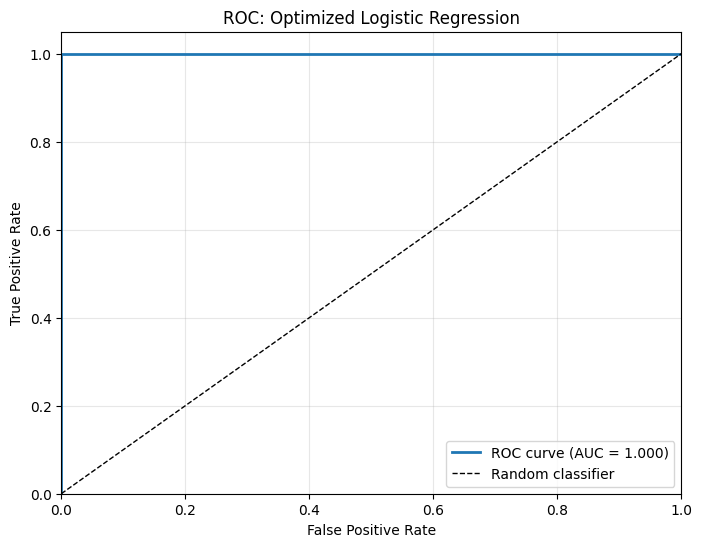

In [5]:
# Re-train best model
best_model = MicrobiomeClassifier(algorithm='logistic', C=best_C, random_state=42)
best_model.fit(dataset.X, dataset.y)

y_probs = best_model.predict_proba(dataset.X)[:, 1]

import matplotlib.pyplot as plt

fig = mf.plot_roc(dataset.y, y_probs, title="ROC: Optimized Logistic Regression")
plt.show()